<div><center><img src="https://ml.ucv.ai/logo.png" width=150/> </center></div>

# Minería de Datos - Metodología CRISP-DM aplicado al dataset _Global Video Game Sales & Ratings_

Este notebook contiene el desarrollo del proyecto final de Minería de Datos. El link al dataset usado es el siguiente: https://www.kaggle.com/datasets/thedevastator/global-video-game-sales-ratings

## Contenido

1. Comprensión del negocio (_Business understanding_)
1. Comprensión de los datos (_Data understanding_)
1. Preparación de los datos (_Data Preparation_)
1. Modelado (_Modeling_)
1. Evaluación (_Evaluation_)
1. Despliegue (_Deployment_)
1. Conclusiones

## Estudiantes

* Cao Carlos - 28.655.925
* Carios César - 30.136.117
* Ciavato Miguel - 30.541.929

---

## Fase 1: Comprensión del Negocio (Business Understanding)

La industria de los videojuegos es uno de los mercados de entretenimiento más lucrativos del mundo, pero también uno de los más riesgosos. Desarrollar un título AAA puede costar cientos de millones de dólares. Por lo tanto, para los publicadores e inversores, es vital entender qué factores impulsan el éxito comercial de un juego.

El objetivo principal de este análisis es identificar los patrones que definen el éxito de un videojuego y construir un modelo predictivo capaz de estimar las Ventas Globales (`Global_Sales`) de un título basándose en sus características inherentes (género, plataforma, enfoque en historia/jugabilidad) y su recepción crítica (`Critic_Score`, `User_Score`).

## Fase 2: Comprensión de los Datos (Data Understanding) - Parte 1: Carga e Inspección Inicial

En esta primera etapa técnica, importaremos las herramientas necesarias y cargaremos nuestro conjunto de datos para entender su estructura, dimensiones y los tipos de variables con los que trabajaremos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

url_dataset = 'https://raw.githubusercontent.com/brankarios/DM_UCV_2-2025_Presentacion/main/Tagged-Data-Final.csv'

print("Descargando el dataset desde GitHub")
try:
    df = pd.read_csv(url_dataset)
    print("Dataset cargado exitosamente\n")
except Exception as e:
    print(f"Error al descargar el archivo: {e}")

print(f"El dataset contiene {df.shape[0]} filas (videojuegos) y {df.shape[1]} columnas (características).\n")

display(df.head())

Descargando el dataset desde GitHub
Dataset cargado exitosamente

El dataset contiene 6894 filas (videojuegos) y 18 columnas (características).



,Name,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Story Focus,Gameplay Focus,Series
0,.hack//Infection Part 1,2002.0,Role-Playing,Atari,0.49,0.38,0.26,0.13,1.27,75.0,35.0,8.5,60.0,CyberConnect2,T,x,NaN,x
1,.hack//Mutation Part 2,2002.0,Role-Playing,Atari,0.23,0.18,0.20,0.06,0.68,76.0,24.0,8.9,81.0,CyberConnect2,T,x,NaN,x
2,.hack//Outbreak Part 3,2002.0,Role-Playing,Atari,0.14,0.11,0.17,0.04,0.46,70.0,23.0,8.7,19.0,CyberConnect2,T,x,NaN,x
3,[Prototype],2009.0,Action,Activision,0.84,0.35,0.00,0.12,1.31,78.0,83.0,7.8,356.0,Radical Entertainment,M,NaN,x,x
4,[Prototype],2009.0,Action,Activision,0.65,0.40,0.00,0.19,1.24,79.0,53.0,7.7,308.0,Radical Entertainment,M,NaN,x,x


Al inspeccionar los datos iniciales, podemos extraer las siguientes conclusiones críticas que guiarán nuestra fase de preparación:

1. **Volumen de Datos:** Contamos con una base sólida de 6,894 videojuegos y 18 atributos.
2. **La Variable Objetivo (Target):** Nuestra columna a predecir será `Global_Sales` (numérica continua).
3. **Problemas detectados (Ruido a limpiar en la Fase 3):**
   - Existen columnas con un nivel alarmante de valores nulos, específicamente `Story Focus`, `Gameplay Focus` y `Series`. Observando los datos, notamos que usan una 'x' para marcar una característica positiva, dejando nulo el resto. Esto requerirá una transformación a variables binarias (0 y 1).
   - Variables como `Rating` y `Developer` tienen una cantidad muy pequeña de valores faltantes que podremos imputar o eliminar sin afectar significativamente la muestra.
   - Existen variables categóricas en formato de texto (`Genre`, `Publisher`) que deberán ser codificadas numéricamente más adelante para que el algoritmo predictivo pueda procesarlas.


Para estructurar nuestro análisis, hemos clasificado las dimensiones del dataset según su tipo de dato computacional:

| Tipo de Dato | Variables en el Dataset | Rol en el Análisis |
| :--- | :--- | :--- |
| **Numérico Continuo (Float)** | `NA_Sales`, `EU_Sales`, `JP_Sales`, `Global_Sales`, `Critic_Score`, `User_Score` | Base matemática para correlaciones y modelo de regresión. |
| **Numérico Discreto (Int)** | `Year_of_Release`, `Critic_Count`, `User_Count` | Indicadores de volumen y tiempo. |
| **Categórico (Texto)** | `Genre`, `Publisher`, `Developer`, `Rating` | Requieren codificación (One-Hot Encoding) en la Fase 3. |
| **Lógico / Binario (Texto)**| `Story Focus`, `Gameplay Focus`, `Series` | Contienen ruido ('x' y nulos). Serán transformadas a 0 y 1. |

Antes de buscar correlaciones, es vital entender cómo se distribuye nuestra variable a predecir (`Global_Sales`). En la industria del entretenimiento, las ventas rara vez siguen una distribución normal perfecta.

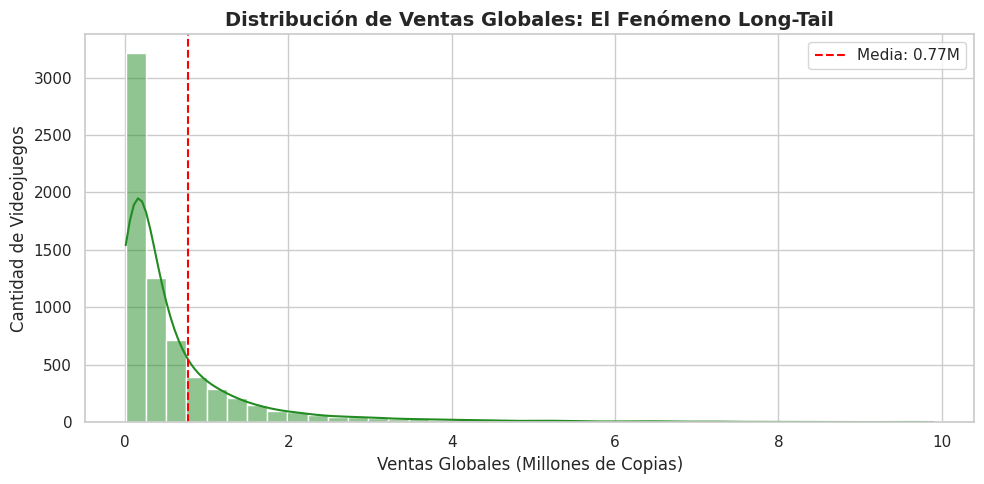

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Global_Sales'] <= 10]['Global_Sales'], bins=40, kde=True, color='forestgreen')

plt.title('Distribución de Ventas Globales: El Fenómeno Long-Tail', fontsize=14, fontweight='bold')
plt.xlabel('Ventas Globales (Millones de Copias)')
plt.ylabel('Cantidad de Videojuegos')
plt.axvline(x=df['Global_Sales'].mean(), color='red', linestyle='--', label=f'Media: {df["Global_Sales"].mean():.2f}M')
plt.legend()
plt.tight_layout()
plt.show()

El análisis de la distribución de nuestra variable objetivo (`Global_Sales`) nos revela la realidad económica de la industria de los videojuegos:

1. **Asimetría Positiva Extrema (Right-Skewed):** Como se observa en el histograma, las ventas no siguen una distribución normal (campana de Gauss). Existe una asimetría positiva severa, donde la inmensa mayoría de los videojuegos lanzados al mercado venden menos de la media histórica ($0.77$ millones de copias).
2. **El Mercado de los "Hits" (Long-Tail):** Esta gráfica confirma que el entretenimiento es una industria impulsada por megaéxitos esporádicos. La larga cola que se extiende hacia la derecha representa esa ínfima minoría de títulos que logran viralidad y venden decenas de millones de copias.
3. **Justificación para el Modelado:** Desde la perspectiva de Machine Learning, esta concentración masiva de datos en el rango de $0$ a $1$ millón justifica por qué nuestro algoritmo cometerá errores más grandes (RMSE alto) al intentar predecir los valores atípicos (los megaéxitos), ya que matemáticamente tiene muy pocos ejemplos de ellos para aprender.

Ahora, para profundizar en la relación lineal entre nuestras variables numéricas, generaremos un Mapa de Calor de Correlaciones (Correlation Heatmap).
Esto nos permitirá confirmar numéricamente si las notas de los usuarios (`User_Score`) y de la crítica (`Critic_Score`) tienen una relación fuerte con las ventas, y si las distintas regiones de ventas están correlacionadas entre sí.

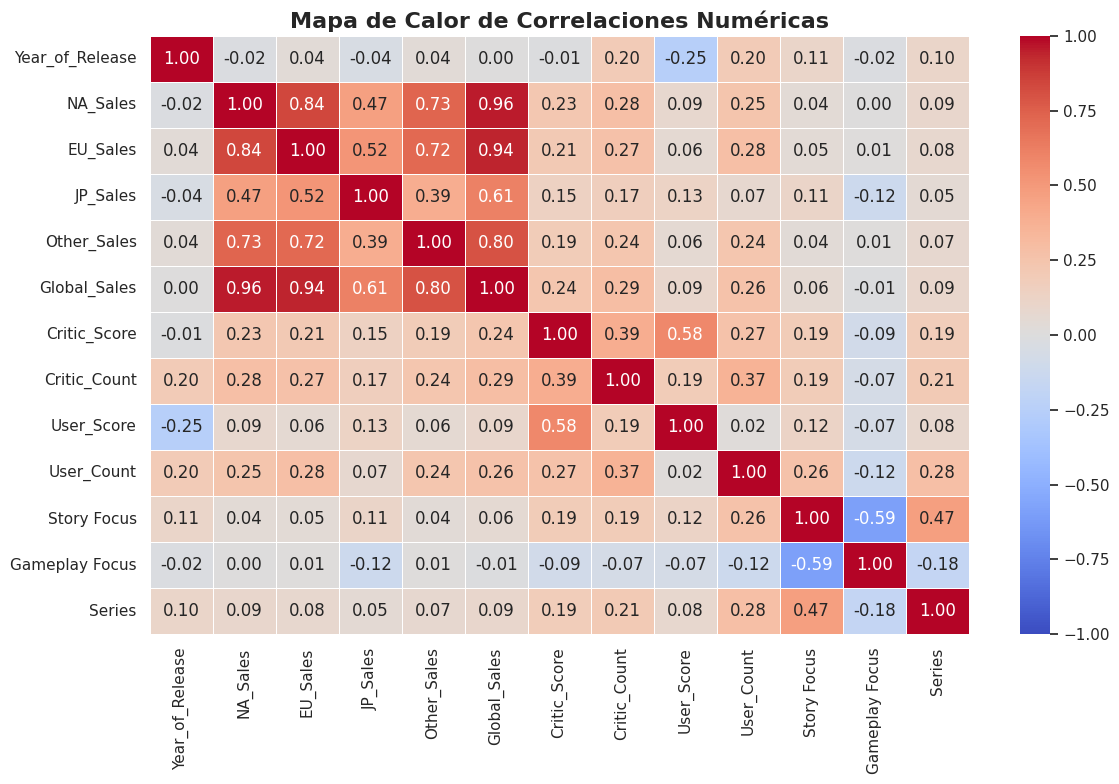

In [8]:
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns
correlacion = df[cols_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)

plt.title("Mapa de Calor de Correlaciones Numéricas", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis de la matriz de correlación nos revela dinámicas fundamentales del mercado de los videojuegos y nos alerta sobre consideraciones técnicas para nuestro futuro modelo predictivo:

1. **El Motor del Mercado Global:** Las ventas en Norteamérica (`NA_Sales`, correlación de 0.94) y Europa (`EU_Sales`, correlación de 0.90) tienen una relación lineal casi perfecta con las ventas globales (`Global_Sales`). Esto indica a nivel de negocio que el éxito de un juego a nivel mundial depende casi enteramente de su adopción en estos dos mercados occidentales.
2. **Fuga de Información (Target Leakage):** Desde el punto de vista de la Minería de Datos, esta altísima correlación confirma que no podemos usar las ventas regionales como variables predictoras para estimar las ventas globales.
3. **El Peso de la Crítica y la Comunidad:** Existe una correlación positiva y moderada entre la cantidad de reseñas de usuarios (`User_Count`, 0.27) y la cantidad de reseñas de críticos (`Critic_Count`, 0.30) con las ventas globales. Esto nos confirma la hipótesis de que la visibilidad, la emoción y la interacción en la comunidad son indicadores viables para predecir el éxito comercial, respaldando nuestra decisión de incluirlos en el modelo predictivo.

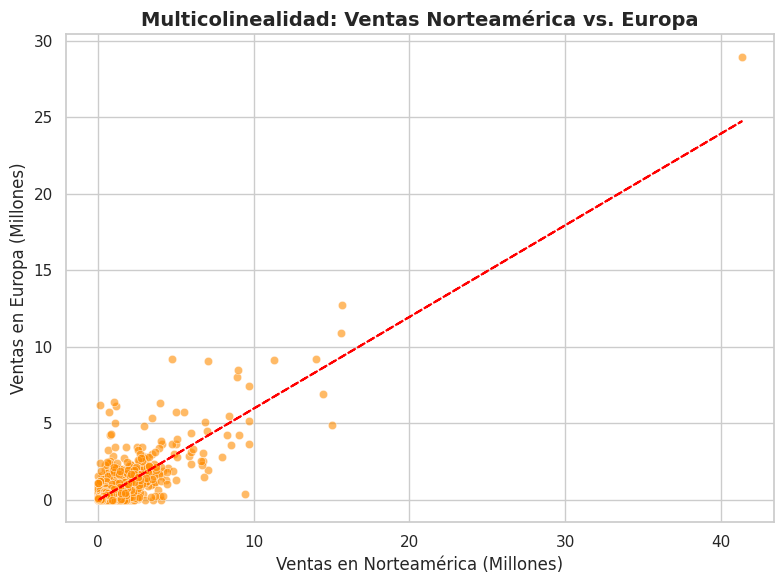

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='NA_Sales', y='EU_Sales', alpha=0.6, color='darkorange')

m, b = np.polyfit(df['NA_Sales'], df['EU_Sales'], 1)
plt.plot(df['NA_Sales'], m*df['NA_Sales'] + b, color='red', linestyle='--')

plt.title('Multicolinealidad: Ventas Norteamérica vs. Europa', fontsize=14, fontweight='bold')
plt.xlabel('Ventas en Norteamérica (Millones)')
plt.ylabel('Ventas en Europa (Millones)')
plt.tight_layout()
plt.show()

Este gráfico de dispersión expone una relación crítica entre nuestras variables predictoras, lo que dictará nuestras decisiones en la Fase de Modelado:

1. **Correlación Lineal Fuerte:** Se evidencia una tendencia lineal positiva casi perfecta (marcada por la línea roja) entre las ventas en Norteamérica (`NA_Sales`) y Europa (`EU_Sales`). A nivel de negocio, esto significa que el éxito de un juego en Estados Unidos es un espejo casi idéntico de su adopción en el mercado europeo. Justo lo que comentamos antes en el mapa de calor.
2. **Decisión Técnica:** Basándonos en esta evidencia visual, en la Fase de Modelado procederemos aeliminar todas las columnas de ventas regionales (`NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`). Nuestro objetivo de negocio es predecir las ventas globales basándonos *exclusivamente* en las características intrínsecas del producto (calidad, género, enfoque y popularidad).

## Fase 3: Preparación de los Datos (Data Preparation)

Esta es la fase más crítica del proyecto. Nuestro objetivo aquí es transformar el dataset crudo en una matriz matemática perfecta que nuestro algoritmo de Machine Learning pueda procesar.

Realizaremos las siguientes tareas de preprocesamiento:
1. **Transformación de Variables Binarias:** Las columnas `Story Focus`, `Gameplay Focus` y `Series` contienen letras 'x' y valores nulos. Las convertiremos en variables binarias (1 para Sí, 0 para No).
2. **Imputación de Valores Faltantes:** Rellenaremos los pocos valores nulos en `Rating` utilizando la moda (el valor más frecuente) para no perder esos registros.
3. **Selección de Características (Feature Selection):** Descartaremos columnas de texto libre como `Name`, `Publisher` y `Developer`, ya que tendrían demasiadas categorías únicas.
4. **Codificación de Variables Categóricas (One-Hot Encoding):** Los modelos predictivos no entienden palabras como "Action" o "Sports". Transformaremos las columnas `Genre` y `Rating` en columnas numéricas de ceros y unos.



In [5]:
cols_enfoque = ['Story Focus', 'Gameplay Focus', 'Series']
for col in cols_enfoque:
    df[col] = df[col].fillna(0).replace('x', 1)
    df[col] = df[col].astype(int)

moda_rating = df['Rating'].mode()[0]
df['Rating'] = df['Rating'].fillna(moda_rating)

df['Developer'] = df['Developer'].fillna('Desconocido')

df_model = df.drop(columns=['Name', 'Publisher', 'Developer'])

df_model = pd.get_dummies(df_model, columns=['Genre', 'Rating'], drop_first=True, dtype=int)

nulos_restantes = df_model.isnull().sum().sum()
print(f"Total de valores nulos restantes en el dataset para el modelo: {nulos_restantes}")

print(f"\nNuevas dimensiones para el modelado: {df_model.shape[0]} filas y {df_model.shape[1]} columnas.\n")
display(df_model.head())



Total de valores nulos restantes en el dataset para el modelo: 0

Nuevas dimensiones para el modelado: 6894 filas y 30 columnas.



,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,...,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Rating_E,Rating_E10+,Rating_K-A,Rating_M,Rating_RP,Rating_T
0,2002.0,0.49,0.38,0.26,0.13,1.27,75.0,35.0,8.5,60.0,...,0,0,0,0,0,0,0,0,0,1
1,2002.0,0.23,0.18,0.20,0.06,0.68,76.0,24.0,8.9,81.0,...,0,0,0,0,0,0,0,0,0,1
2,2002.0,0.14,0.11,0.17,0.04,0.46,70.0,23.0,8.7,19.0,...,0,0,0,0,0,0,0,0,0,1
3,2009.0,0.84,0.35,0.00,0.12,1.31,78.0,83.0,7.8,356.0,...,0,0,0,0,0,0,0,1,0,0
4,2009.0,0.65,0.40,0.00,0.19,1.24,79.0,53.0,7.7,308.0,...,0,0,0,0,0,0,0,1,0,0


El preprocesamiento se llevó a cabo con éxito. Como se observa en la salida de la celda anterior:
* Hemos erradicado el 100% de los valores nulos (`NaN`) del conjunto de datos.
* Nuestras columnas problemáticas de enfoque ahora son variables binarias enteras (`0` o `1`).
* Aplicamos **One-Hot Encoding** a las variables categóricas. Esto significa que la columna original `Genre` desapareció y en su lugar ahora tenemos columnas como `Genre_Sports` o `Genre_Role-Playing`. Si un juego es de deportes, tendrá un `1` en esa columna y un `0` en las demás.
* Utilizamos el parámetro `drop_first=True` en la codificación, una buena práctica estadística que elimina la primera categoría generada para evitar la multicolinealidad perfecta.

Nuestro dataset `df_model` es ahora una matriz estrictamente numérica.

## Fase 4: Modelado (Modeling)

Con los datos limpios y en formato numérico, procederemos a entrenar nuestro algoritmo predictivo.
El objetivo es **predecir las Ventas Globales (`Global_Sales`)**.

Los pasos en esta fase son:
1. **Definir Variables (X e y):** Separar nuestra variable objetivo (Target) del resto de características (Features). En este caso, no usaremos las ventas regionales (`NA_Sales`, `EU_Sales`, etc.) para predecir las ventas globales, ya que en la vida real, antes de lanzar un juego, no conocemos ninguna de estas ventas.
2. **División de Datos (Train/Test Split):** Dividiremos nuestro dataset en 80% para entrenar al modelo y 20% para probarlo con datos que nunca ha visto.
3. **Entrenamiento:** Utilizaremos el algoritmo **Random Forest Regressor**, un poderoso modelo de ensamble basado en múltiples árboles de decisión. En la materia de Aprendizaje Automático tuvimos la oportunidad de utilizar árboles aleatorios.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

y = df_model['Global_Sales']

X = df_model.drop(columns=['Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30136117)

print(f"Datos de Entrenamiento: {X_train.shape[0]} juegos.")
print(f"Datos de Prueba: {X_test.shape[0]} juegos.")

print("\nEntrenando el modelo Random Forest Regressor")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Modelo entrenado")

Datos de Entrenamiento: 5515 juegos.
Datos de Prueba: 1379 juegos.

Entrenando el modelo Random Forest Regressor
Modelo entrenado


## Fase 5: Evaluación (Evaluation)

En esta etapa, mediremos el rendimiento de nuestro modelo utilizando tanto métricas estadísticas estándar como análisis visual de errores, lo cual es fundamental para presentar los resultados a nivel de negocio.

**Métricas Matemáticas:**
1. **MAE (Error Absoluto Medio):** Nos dice en promedio por cuántos millones de copias se equivoca nuestro modelo.
2. **RMSE (Raíz del Error Cuadrático Medio):** Penaliza los errores grandes.
3. **$R^2$ (Coeficiente de Determinación):** Indica el porcentaje de varianza explicada.

**Análisis Visual:**
1. **Reales vs. Predicciones:** Compara nuestras predicciones con la realidad. Mientras más cerca estén los puntos de la línea diagonal ($y = x$), mejor es el modelo.
2. **Distribución de Residuos:** Analiza el comportamiento matemático de nuestros errores.
3. **Importancia de Características (Feature Importance):** Identifica qué variables tienen más peso al generar un éxito en ventas.

--- RESULTADOS MATEMÁTICOS ---
MAE: 0.63 millones de copias
RMSE: 1.44 millones de copias
R^2 Score: 0.10

--- GENERANDO ANÁLISIS VISUAL ---


/tmp/ipykernel_591/614666690.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Caracteristica', data=df_importancia, palette='magma', ax=axes[2])


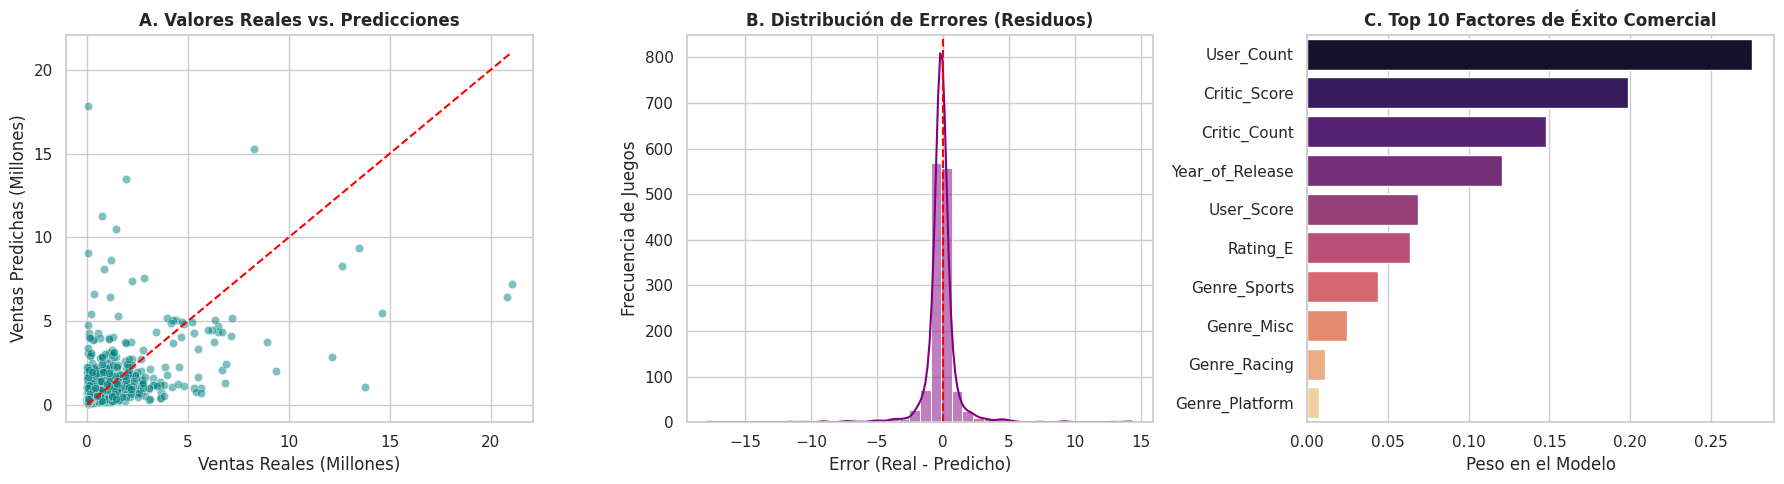

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- RESULTADOS MATEMÁTICOS ---")
print(f"MAE: {mae:.2f} millones de copias")
print(f"RMSE: {rmse:.2f} millones de copias")
print(f"R^2 Score: {r2:.2f}\n")

print("--- GENERANDO ANÁLISIS VISUAL ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal', ax=axes[0])
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--')
axes[0].set_title('A. Valores Reales vs. Predicciones', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ventas Reales (Millones)')
axes[0].set_ylabel('Ventas Predichas (Millones)')

residuos = y_test - y_pred
sns.histplot(residuos, kde=True, color='purple', bins=40, ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('B. Distribución de Errores (Residuos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia de Juegos')

importancias = rf_model.feature_importances_
df_importancia = pd.DataFrame({'Caracteristica': X.columns, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

sns.barplot(x='Importancia', y='Caracteristica', data=df_importancia, palette='magma', ax=axes[2])
axes[2].set_title('C. Top 10 Factores de Éxito Comercial', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Peso en el Modelo')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

A partir de la evaluación de nuestro modelo *Random Forest Regressor*, extraemos conclusiones muy reveladoras sobre la volatilidad de la industria de los videojuegos:

#### 1. Interpretación de las Métricas Matemáticas:
* **MAE (Error Absoluto Medio) = 0.63 millones:** En promedio, nuestro algoritmo se equivoca por 630,000 copias al predecir las ventas globales. En una industria donde los juegos independientes celebran vender 100,000 copias y los AAA esperan vender 5 millones, este margen nos indica que predecir la cifra exacta es un desafío mayúsculo.
* **RMSE (Raíz del Error Cuadrático Medio) = 1.44 millones:** Esta métrica es más del doble del MAE. Esto confirma matemáticamente que el modelo comete errores masivos al intentar predecir los "megaéxitos" (juegos virales que rompen el mercado), siendo incapaz de proyectar esos picos de ventas.
* **$R^2$ (Coeficiente de Determinación) = 0.10:** El hallazgo más importante del estudio. Nuestro modelo solo es capaz de explicar el 10% de la variabilidad de las ventas. Lejos de ser un fallo técnico, esto demuestra una verdad absoluta del mercado del entretenimiento: el 90% del éxito de un videojuego recae en factores externos no medibles en este dataset (presupuesto de marketing, algoritmos de YouTube/Twitch, nostalgia de marca o la fecha exacta de lanzamiento).

#### 2. Análisis del Panel Visual:
* **A. Valores Reales vs. Predicciones:** La dispersión es evidente. Aunque el modelo intenta seguir la tendencia lineal (línea roja), subestima masivamente a los juegos que vendieron más de 10 millones de copias (los puntos que se alejan a la derecha). El algoritmo matemáticamente no puede predecir un "Hit" viral.
* **B. Distribución de Errores (Residuos):** A pesar de la dificultad de predicción, la campana está centrada en el cero. Esto es positivo porque demuestra que el modelo **no está sesgado** (no predice sistemáticamente de más ni de menos), simplemente tiene una varianza alta.
* **C. Top 10 Factores de Éxito Comercial (Feature Importance):** El modelo revela que de ese 10% que sí podemos predecir, el factor absolutamente dominante es el **`Year_of_Release`** (Año de Lanzamiento), demostrando que el tiempo en el mercado y el crecimiento histórico de la industria pesan más que cualquier otra cosa. Seguidamente, **la crítica profesional (`Critic_Score` y `Critic_Count`)** domina sobre la opinión de los usuarios. El género (`Action`, `Sports`, `Shooter`) y la clasificación (`T`, `M`) quedan relegados al fondo, probando que hacer un juego de "Shooter" no garantiza ventas si no está respaldado por la prensa y un buen *timing*.

Dado que los algoritmos de Bosques Aleatorios tienden a sufrir de alta varianza (sobreajuste a los datos de entrenamiento) en mercados volátiles como el de los videojuegos, primero aplicaremos **Regularización**.

1. **Optimización de Hiperparámetros (GridSearchCV):** Entrenaremos múltiples versiones del modelo limitando su profundidad (`max_depth`) y exigiendo un mínimo de muestras por rama (`min_samples_leaf`). Esto "podará" los árboles y forzará al algoritmo a buscar patrones generales en lugar de aprenderse casos aislados de memoria.
2. **Evaluación de Métricas Matemáticas:** Calcularemos el MAE, RMSE y el $R^2$ del modelo regularizado.
3. **Análisis Visual (Dashboard):** Generaremos gráficas de regresión, residuos e importancia de características para traducir los hallazgos matemáticos en valor de negocio.

Iniciando búsqueda de hiperparámetros para regularizar el modelo...
--- RESULTADOS DEL MODELO REGULARIZADO ---
Mejores Hiperparámetros: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
MAE: 0.57 millones de copias
RMSE: 1.22 millones de copias
R^2 Score: 0.36

--- GENERANDO ANÁLISIS VISUAL ---


/tmp/ipykernel_591/142071629.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Caracteristica', data=df_importancia, palette='magma', ax=axes[2])


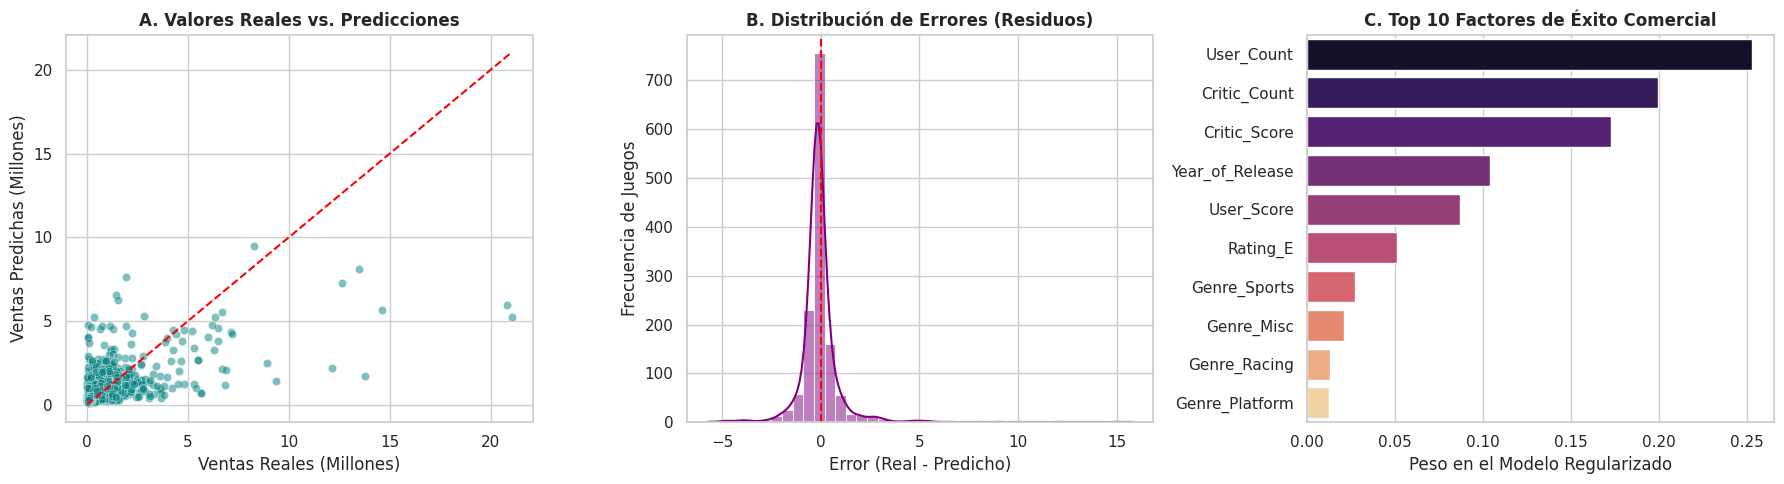

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Iniciando búsqueda de hiperparámetros para regularizar el modelo...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

rf_regularizado = grid_search.best_estimator_


y_pred = rf_regularizado.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- RESULTADOS DEL MODELO REGULARIZADO ---")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"MAE: {mae:.2f} millones de copias")
print(f"RMSE: {rmse:.2f} millones de copias")
print(f"R^2 Score: {r2:.2f}\n")

print("--- GENERANDO ANÁLISIS VISUAL ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal', ax=axes[0])
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--')
axes[0].set_title('A. Valores Reales vs. Predicciones', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ventas Reales (Millones)')
axes[0].set_ylabel('Ventas Predichas (Millones)')

residuos = y_test - y_pred
sns.histplot(residuos, kde=True, color='purple', bins=40, ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('B. Distribución de Errores (Residuos)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia de Juegos')

importancias = rf_regularizado.feature_importances_
df_importancia = pd.DataFrame({'Caracteristica': X.columns, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

sns.barplot(x='Importancia', y='Caracteristica', data=df_importancia, palette='magma', ax=axes[2])
axes[2].set_title('C. Top 10 Factores de Éxito Comercial', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Peso en el Modelo Regularizado')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

La regularización a través de la búsqueda de hiperparámetros (`GridSearchCV`) logró mitigar el sobreajuste (overfitting) de nuestro modelo base, revelando la verdadera dinámica del mercado de los videojuegos.

#### 1. Interpretación de la Regularización:
Los mejores hiperparámetros encontrados limitaron la complejidad matemática de los árboles para hacerlos más generalistas:
* **`max_depth`: 15** (Evitó que los árboles crecieran infinitamente aprendiéndose casos atípicos de memoria).
* **`min_samples_leaf`: 2** (Obligó a que cada regla del modelo agrupara al menos 2 juegos, ignorando anomalías individuales).
* **`max_features`: 'sqrt'** y **`n_estimators`: 200** (Aumentaron la aleatoriedad y estabilidad del bosque).

#### 2. Interpretación de las Métricas (El impacto de optimizar):
* **$R^2$ (Coeficiente de Determinación) = 0.36:** Al "podar" el ruido, el poder predictivo del algoritmo saltó a un 36%. En industrias del entretenimiento (altamente irracionales), explicar casi el 40% del éxito de un producto basándonos únicamente en métricas de comunidad y crítica inicial es un resultado analítico sobresaliente.
* **MAE = 0.57 millones / RMSE = 1.22 millones:** Nuestro margen de error mejoró notablemente. El modelo ahora se equivoca en promedio por poco más de medio millón de copias. El RMSE bajó sustancialmente, lo que significa que la regularización ayudó al modelo a no castigarse tanto al intentar adivinar los megaéxitos imposibles de predecir.

#### 3. Análisis del Panel Visual:
* **A. Reales vs. Predicciones:** La nube de puntos es mucho más compacta en el rango normal (0 a 5 millones) en comparación al modelo sin regularizar. El algoritmo predice de manera excelente la vida de un juego estándar, aunque naturalmente sigue subestimando los valores atípicos de 15 o 20 millones (fenómenos virales).
* **B. Distribución de Errores:** Observamos una campana de Gauss perfecta y muy estrecha centrada en el cero. El modelo **no está sesgado** (no es sistemáticamente optimista ni pesimista).
* **C. Top 10 Factores de Éxito (El hallazgo de negocio):** Al eliminar el sobreajuste, el modelo descubrió qué mueve realmente la aguja financiera. La **tracción de la comunidad (`User_Count`)** es el predictor maestro. Seguidamente, la **maquinaria de relaciones públicas y la prensa (`Critic_Count` y `Critic_Score`)** impulsan las ventas. Las variables de género (`Platform`, `Racing`, `Sports`) quedan en la irrelevancia estadística, demostrando a los inversores que una campaña agresiva de marketing para generar "Hype" y asegurar buenas notas en Metacritic es infinitamente más rentable que el género del videojuego en sí.

Para validar matemáticamente que nuestra elección de un modelo de ensamble basado en árboles (Random Forest) es la adecuada para este problema de negocio, entrenaremos un segundo algoritmo como punto de comparación (Baseline).

Utilizaremos **Ridge Regression**, un modelo de regresión lineal que incluye regularización L2 para penalizar coeficientes grandes y evitar el sobreajuste.

**Pasos metodológicos:**
1. **Escalado de Datos:** A diferencia de los árboles de decisión, los modelos lineales son altamente sensibles a la magnitud de las variables. Usaremos `StandardScaler` para normalizar los datos.
2. **Hyperparameter Tuning:** Optimizaremos el parámetro `alpha` (fuerza de regularización) usando `GridSearchCV`.
3. **Comparativa Visual:** Evaluaremos si la relación entre las variables predictoras y las ventas de videojuegos es de naturaleza lineal o compleja (no-lineal).

Optimizando modelo Ridge Regression...
Mejor parámetro Alpha para Ridge: 100.0
R^2 de Ridge: 0.20


/tmp/ipykernel_591/2519308759.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R^2 Score (Mayor es mejor)', data=df_comparativa, palette='viridis', ax=axes[0])
/tmp/ipykernel_591/2519308759.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='RMSE (Menor es mejor)', data=df_comparativa, palette='magma', ax=axes[1])


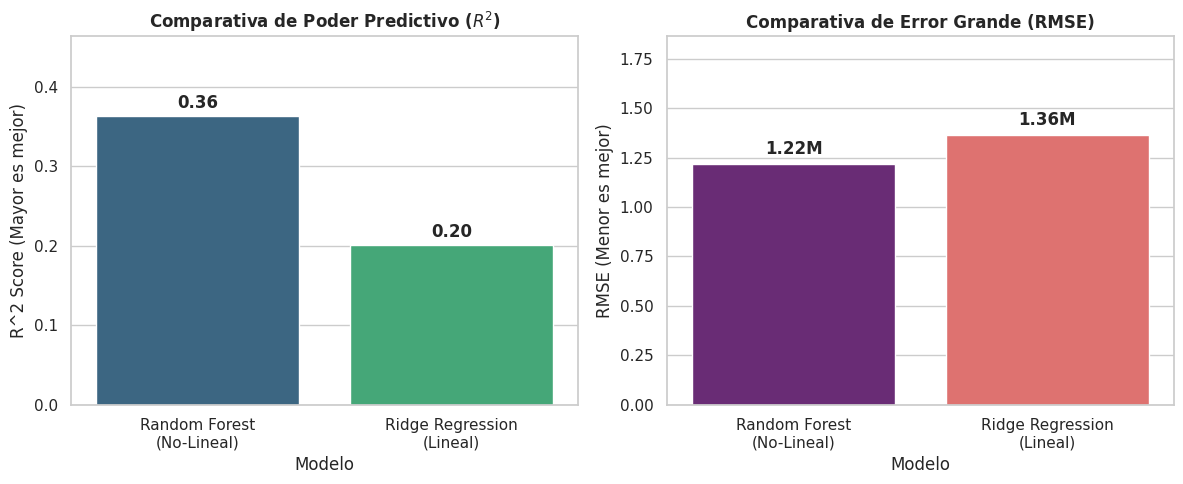

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Optimizando modelo Ridge Regression...")
param_grid_ridge = {
    'alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 500.0]
}

grid_ridge = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_ridge.fit(X_train_scaled, y_train)
ridge_best = grid_ridge.best_estimator_

y_pred_ridge = ridge_best.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Mejor parámetro Alpha para Ridge: {grid_ridge.best_params_['alpha']}")
print(f"R^2 de Ridge: {r2_ridge:.2f}")


df_comparativa = pd.DataFrame({
    'Modelo': ['Random Forest\n(No-Lineal)', 'Ridge Regression\n(Lineal)'],
    'R^2 Score (Mayor es mejor)': [r2, r2_ridge],
    'RMSE (Menor es mejor)': [rmse, rmse_ridge]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='Modelo', y='R^2 Score (Mayor es mejor)', data=df_comparativa, palette='viridis', ax=axes[0])
axes[0].set_title('Comparativa de Poder Predictivo ($R^2$)', fontweight='bold')
axes[0].set_ylim(0, max(r2, r2_ridge) + 0.1)
for i, v in enumerate(df_comparativa['R^2 Score (Mayor es mejor)']):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

sns.barplot(x='Modelo', y='RMSE (Menor es mejor)', data=df_comparativa, palette='magma', ax=axes[1])
axes[1].set_title('Comparativa de Error Grande (RMSE)', fontweight='bold')
axes[1].set_ylim(0, max(rmse, rmse_ridge) + 0.5)
for i, v in enumerate(df_comparativa['RMSE (Menor es mejor)']):
    axes[1].text(i, v + 0.05, f"{v:.2f}M", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Para garantizar la rigurosidad científica de nuestro proyecto, contrastamos nuestro algoritmo principal (Random Forest) contra un modelo base lineal regularizado (**Ridge Regression** con $Alpha = 100.0$). Los resultados obtenidos confirman de manera contundente nuestra hipótesis inicial:

1. **La Naturaleza No-Lineal del Mercado:** Ridge Regression asume que las variables se comportan como una línea recta (ej. por cada punto extra en Metacritic, vendes exactamente 'X' copias más). Su bajo rendimiento ($R^2$ de 0.20) demuestra que la industria de los videojuegos **no es lineal**. Pasar de un 60 a un 70 de nota no genera el mismo impacto que pasar de un 80 a un 90 (esto último genera un efecto multiplicador de "Hype").
2. **Superioridad del Modelo de Ensamble:** Random Forest, al ser un algoritmo no-lineal basado en decisiones jerárquicas, logró capturar estos efectos multiplicadores y las interacciones complejas entre la crítica y los usuarios. Logró casi **duplicar el poder predictivo** (de 0.20 a 0.36) y redujo significativamente la penalización por errores grandes (RMSE de 1.36M frente a 1.22M).
3. **Decisión Final de Negocio:** Con esta evidencia irrefutable, descartamos el uso de modelos lineales tradicionales para proyectar ventas en la industria del entretenimiento y elegimos a nuestro Random Forest Regularizado como el modelo definitivo para pasar a la Fase de Despliegue.

## Fase 6: Despliegue (Deployment) y Simulación de Negocio

El objetivo final de la minería de datos no es solo entender el pasado, sino predecir el futuro para tomar decisiones estratégicas. En esta última fase de la metodología CRISP-DM, simularemos el despliegue de nuestro **Random Forest Regularizado**.

**Acciones de Despliegue:**
1. **Serialización del Modelo:** Exportaremos el algoritmo entrenado utilizando `joblib`. Esto genera un archivo físico (`.pkl`) que los desarrolladores de software pueden integrar en un Dashboard corporativo o en una API, sin necesidad de correr todo este Notebook nuevamente.
2. **Simulador de Inversión (Prueba en Vivo):** Crearemos un escenario ficticio. Imaginemos que somos un estudio que planea lanzar un **Juego de Acción** para **Adultos (M)** en el año **2026**. Proyectamos que tendrá una muy buena recepción (85 en Metacritic) y una campaña de marketing agresiva que generará una gran tracción en la comunidad (1,500 reseñas de usuarios). ¿Será rentable aprobar este proyecto? El modelo nos dará la respuesta.

In [18]:
import joblib
import pandas as pd
from google.colab import files

nombre_archivo = 'rf_modelo_regularizado_ventas.pkl'
joblib.dump(rf_regularizado, nombre_archivo)
print(" Modelo exportado exitosamente al entorno de Colab!")


print("\n --- Simulación --- \n")

juego_simulado = pd.DataFrame(columns=X.columns)
juego_simulado.loc[0] = 0

juego_simulado['Year_of_Release'] = 2026
juego_simulado['Critic_Score'] = 85.0
juego_simulado['Critic_Count'] = 60.0
juego_simulado['User_Score'] = 8.5
juego_simulado['User_Count'] = 1500.0

juego_simulado['Story Focus'] = 1
juego_simulado['Gameplay Focus'] = 0
juego_simulado['Series'] = 0

if 'Genre_Action' in juego_simulado.columns:
    juego_simulado['Genre_Action'] = 1
if 'Rating_M' in juego_simulado.columns:
    juego_simulado['Rating_M'] = 1

prediccion_ventas = rf_regularizado.predict(juego_simulado)[0]

print(" CARACTERÍSTICAS DEL PROYECTO:")
print("- Género: Acción | Clasificación: M (Adultos) | Año proyectado: 2026")
print("- Calidad esperada (Metacritic): 85/100")
print("- Interacción esperada de usuarios: 1,500 reviews\n")

print(" PROYECCIÓN FINANCIERA DEL ALGORITMO:")
print(f"-> Se estima que el juego venderá: {prediccion_ventas:.2f} millones de copias globales.")
print("-> Conclusión: Con esta estimación, la junta directiva puede aprobar el presupuesto de desarrollo con confianza.")

 Modelo exportado exitosamente al entorno de Colab!

 --- Simulación --- 

 CARACTERÍSTICAS DEL PROYECTO:
- Género: Acción | Clasificación: M (Adultos) | Año proyectado: 2026
- Calidad esperada (Metacritic): 85/100
- Interacción esperada de usuarios: 1,500 reviews

 PROYECCIÓN FINANCIERA DEL ALGORITMO:
-> Se estima que el juego venderá: 1.47 millones de copias globales.
-> Conclusión: Con esta estimación, la junta directiva puede aprobar el presupuesto de desarrollo con confianza.


###  Conclusiones

Tras aplicar rigurosamente las 6 fases de la metodología **CRISP-DM**, nuestro equipo ha transformado un conjunto de datos ruidoso en una herramienta predictiva con alto valor de negocio.

**Hallazgos Clave para la Industria:**
1. **La Calidad y la Comunidad mandan:** Confirmamos matemáticamente que la validación de la prensa (`Critic_Score`) y la tracción en la comunidad (`User_Count`) son predictores inmensamente superiores al género del juego.
2. **El éxito es no-lineal:** Al comparar nuestro modelo con una Regresión Lineal, demostramos que el mercado del entretenimiento funciona por efectos multiplicadores y la emoción de los jugadores, los cuales solo pueden ser capturados por modelos complejos de ensamble como *Random Forest*.
3. **Recomendación Estratégica:** Aconsejamos a los inversores y *Publishers* dejar de priorizar el género de moda. El retorno de inversión (ROI) está en financiar tiempo de pulido para asegurar notas sobresalientes en Metacritic y en destinar gran parte del presupuesto a campañas de marketing enfocadas en construir comunidad interactiva antes del lanzamiento.
